In [7]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('/home/hxcai/cell_type_specific_CRE')
from MPRA_exp.utils import *

import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [2]:
# info_df = pd.read_csv('./data/enformer_info.csv')
# info_df = info_df.replace('-', '', regex=True)
# info_df

info_df = pd.read_csv('./data/sei_info.csv')
info_df = info_df.replace('-', '', regex=True)
info_df

,cell_type,assay,ID,part
0,HeLa_Epithelium_Cervix,BTAF1,ID:1,0
1,H9_Embryonic_Stem_Cell_Embryo,EOMES,ID:1006,0
2,H9_Embryonic_Stem_Cell_Embryo,EP300,ID:1007,0
3,H9_Embryonic_Stem_Cell_Embryo,FOXH1,ID:1010,0
4,H9_Embryonic_Stem_Cell_Embryo,FOXH1,ID:1011,0
...,...,...,...,...
21902,WERIRb1,CTCF,ENCODE,0
21903,WERIRb1,DNase,ENCODE,0
21904,WI38,CTCF,ENCODE,0
21905,WI38 (4OHTAM_20nM_72hr),DNase,ENCODE,0


In [3]:
def logit(x):
    return np.log(x/(1-x))


def find_indice(info_df, cell_type='', assay=''):
    mask = info_df['cell_type'].str.contains(cell_type, case=False) & info_df['assay'].str.contains(assay, case=False)
    indice = info_df[mask].index
    print(f'{cell_type} {assay} {len(indice)} data found.')
    
    return indice


def find_indice_precise(info_df, cell_types=[], assays=[]):
    if not cell_types and not assays:
        print('both cell_types and assays are empty, return all indices.')
        return info_df.index
    # Create masks based on the provided criteria
    cell_type_mask = info_df['cell_type'].isin(cell_types) if cell_types else True
    assay_mask = info_df['assay'].isin(assays) if assays else True

    # Combine masks
    mask = cell_type_mask & assay_mask
    indice = info_df[mask].index

    print(f'{cell_types} {assays} {len(indice)} data found.')

    return indice


def compute_pred(main_df, info_df, pred_array, cell_type, assay):
    filtered_indice = find_indice(info_df, cell_type, assay)
    if len(filtered_indice) == 0:
        return

    print(info_df.iloc[filtered_indice])
    for i in filtered_indice:
        print(f'pearson r between true and {i} = {pearsonr(main_df[cell_type], pred_array[:, i])}')
    # for i in filtered_indice:
    #     print(f'pearson r between encode and {i} = {pearsonr(Gosai_designed_sei_pred[:, i], Gosai_designed_sei_pred[:, i])}')
    main_df[f'{cell_type}_{assay}_pred'] = pred_array[:, filtered_indice].mean(axis=1)
    # main_df[f'{cell_type}_{assay}_pred_logit'] = logit(main_df[f'{cell_type}_{assay}_pred'])

    return pred_array[:, filtered_indice].mean(axis=1)


def plot(main_df, cell_type, assay):
    x = main_df[f'{cell_type}_{assay}_pred']
    y = main_df[cell_type]
    r = pearsonr(x, y)[0]
    print(f'pearson r = {r:.3f}')

    fig, ax = plt.subplots(figsize=(8, 6), dpi=50)
    left, right, bottom, top = 0.13, 0.93, 0.15, 0.95
    ax.set_position([left, bottom, right - left, top - bottom])
    sns.scatterplot(x=x, y=y, s=1, edgecolor=None, ax=ax)
    ax.set_xlabel(f'{cell_type}_{assay}_pred')
    ax.set_ylabel(f'{cell_type}_MPRA_true')
    ax.text(x=0.1, y=0.9, s=f'pearson r = {r:.3f}', transform=ax.transAxes, fontsize=16)
    plt.savefig(f'figures/{cell_type}_{assay}_pred.png', dpi=200)


def plot_logit(main_df, cell_type, assay):
    x = logit(main_df[f'{cell_type}_{assay}_pred'])
    y = main_df[cell_type]
    r = pearsonr(x, y)[0]
    print(f'pearson r = {r:.3f}')

    plot_scatter(x, y, 
                 xlabel=f'{cell_type}_{assay}_pred_logit', 
                 ylabel=f'{cell_type}_MPRA_true', 
                 text=f'pearson r = {r:.3f}', 
                 title=f'', 
                 filename=f'{cell_type}_{assay}_pred_logit')

    # fig, ax = plt.subplots(figsize=(8, 6), dpi=50)
    # left, right, bottom, top = 0.13, 0.93, 0.15, 0.95
    # ax.set_position([left, bottom, right - left, top - bottom])
    # sns.scatterplot(x=x, y=y, s=1, edgecolor=None, ax=ax)
    # ax.set_xlabel(f'{cell_type}_{assay}_pred_logit')
    # ax.set_ylabel(f'{cell_type}_MPRA_true')
    # ax.text(x=0.1, y=0.9, s=f'pearson r = {r:.3f}', transform=ax.transAxes, fontsize=16)
    # plt.savefig(f'figures/{cell_type}_{assay}_pred_logit.png', dpi=200)

    # plt.figure(figsize=(8, 6), dpi=50)
    # sns.scatterplot(x=x, y=y, s=1, edgecolor=None)
    # plt.xlabel(f'{cell_type}_{assay}_pred_logit')
    # plt.ylabel(f'{cell_type}_MPRA_true')
    # plt.text(x=0.1, y=0.9, s=f'pearson r = {r:.3f}', transform=plt.gca().transAxes, fontsize=16)
    # plt.savefig(f'figures/{cell_type}_{assay}_pred_logit.png', dpi=300, bbox_inches='tight')


def plot_scatter(x, y, xlabel='', ylabel='', text='', title='', filename=''):
    fig, ax = plt.subplots(figsize=(8, 6), dpi=50)
    left, right, bottom, top = 0.13, 0.93, 0.15, 0.95
    ax.set_position([left, bottom, right - left, top - bottom])
    sns.scatterplot(x=x, y=y, s=1, edgecolor=None, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.text(x=0.1, y=0.9, s=text, transform=ax.transAxes, fontsize=16)
    plt.title(title)
    plt.savefig(f'figures/{filename}.png', dpi=200)


def plot_logit_diff(main_df, cell_type1, cell_type2, assay):
    x = logit(main_df[f'{cell_type1}_{assay}_pred']) - logit(main_df[f'{cell_type2}_{assay}_pred'])
    y = main_df[cell_type1] - main_df[cell_type2]

    r = pearsonr(x, y)[0]
    print(f'pearson r = {r:.3f}')

    fig, ax = plt.subplots(figsize=(8, 6), dpi=50)
    left, right, bottom, top = 0.13, 0.93, 0.15, 0.95
    ax.set_position([left, bottom, right - left, top - bottom])
    sns.scatterplot(x=x, y=y, s=1, edgecolor=None, ax=ax)
    ax.set_xlabel(f'{cell_type1}_{cell_type2}_{assay}_pred_logit_diff')
    ax.set_ylabel(f'{cell_type1}_{cell_type2}_MPRA_true_diff')
    ax.text(x=0.1, y=0.9, s=f'pearson r = {r:.3f}', transform=ax.transAxes, fontsize=16)
    plt.savefig(f'figures/{cell_type1}_{cell_type2}_{assay}_pred_logit_diff.png', dpi=200)

In [4]:
# # Gosai_designed_sei_embedding = np.load('data/Gosai_designed_sei_embedding.npy')
# # print(Gosai_designed_sei_embedding.shape)

# Gosai_designed_sei_pred = np.load('data/GosaiMPRA/Gosai_designed_sei_pred.npy')
# print(Gosai_designed_sei_pred.shape)

# main_df = pd.read_csv('/home/hxcai/cell_type_specific_CRE/data/GosaiMPRA/GosaiMPRA_designed.csv', sep='\t')
# print(main_df.shape)

(56975, 21907)


In [10]:
Sei_pred = np.load('data/AgarwalMPRA/sei_joint_pred.npy')
print(Sei_pred.shape)

main_df = pd.read_csv('../data/AgarwalMPRA/joint_table.csv')
print(main_df.shape)

(56975, 21907)
(56975, 5)


In [11]:
# cell_types = ['HepG2', 'K562']
# cell_types = ['HepG2', 'K562', 'SKNSH']
cell_types = ['HepG2', 'K562', 'WTC11']

# check all possible cell type names
for cell_type in cell_types:
    indice = find_indice(info_df, cell_type, '')
    # print(set(info_df.iloc[indice]['cell_type']))

HepG2  386 data found.
K562  1233 data found.
WTC11  0 data found.


In [12]:
# define correct cell type names
cell_types_possible_dict = {
    'HepG2': ['HepG2', 'HepG2_Hepatocellular_Carcinoma', 'HepG2_Epithelium_Liver', 'HepG2_hepatocellular_carcinoma'],
    'K562' : ['K562', 'K562_Leukemia_Bone', 'K562_Leukemia_Cell', 'K562_Leukemia', 'K562_Lymphoblast', 'K562_human_erythroleukemic_cell_line', 'K562_Haematopoietic_and_lymphoid'],
    'SKNSH': ['SKNSH', 'SKNSH_Neuroblastoma_cell_Brain'],
    'WTC11': ['iPSC'],
}

In [13]:
# find intersect assays
cell_type_specific_assays_list = []
for cell_type in cell_types:
    indice = find_indice_precise(info_df, cell_types=cell_types_possible_dict[cell_type], assays=[])
    unique_assays = set(info_df.iloc[indice]['assay'])
    print(f'{cell_type} {len(unique_assays)} unique assays')
    cell_type_specific_assays_list.append(unique_assays)

intersect_assays = list(set.intersection(*cell_type_specific_assays_list))
print(f'{len(intersect_assays)} intersect assays found.')
save_txt('data/intersect_assays.txt', intersect_assays)

# compute SEI prediction for each cell type and assay
assays = load_txt('data/intersect_assays.txt')
for cell_type in cell_types:
    for assay in assays:
        indice = find_indice_precise(info_df, cell_types=cell_types_possible_dict[cell_type], assays=[assay])
        value = Sei_pred[:, indice].mean(axis=1)
        main_df[f'{cell_type}_{assay}_pred'] = value
        main_df[f'{cell_type}_{assay}_pred_logit'] = logit(value)
main_df = main_df.copy()

['HepG2', 'HepG2_Hepatocellular_Carcinoma', 'HepG2_Epithelium_Liver', 'HepG2_hepatocellular_carcinoma'] [] 378 data found.
HepG2 157 unique assays
['K562', 'K562_Leukemia_Bone', 'K562_Leukemia_Cell', 'K562_Leukemia', 'K562_Lymphoblast', 'K562_human_erythroleukemic_cell_line', 'K562_Haematopoietic_and_lymphoid'] [] 191 data found.
K562 132 unique assays
['iPSC'] [] 90 data found.
WTC11 20 unique assays
9 intersect assays found.
['HepG2', 'HepG2_Hepatocellular_Carcinoma', 'HepG2_Epithelium_Liver', 'HepG2_hepatocellular_carcinoma'] ['H3K4me1'] 4 data found.
['HepG2', 'HepG2_Hepatocellular_Carcinoma', 'HepG2_Epithelium_Liver', 'HepG2_hepatocellular_carcinoma'] ['H3K9me3'] 2 data found.
['HepG2', 'HepG2_Hepatocellular_Carcinoma', 'HepG2_Epithelium_Liver', 'HepG2_hepatocellular_carcinoma'] ['H3K27me3'] 2 data found.
['HepG2', 'HepG2_Hepatocellular_Carcinoma', 'HepG2_Epithelium_Liver', 'HepG2_hepatocellular_carcinoma'] ['EZH2'] 2 data found.
['HepG2', 'HepG2_Hepatocellular_Carcinoma', 'HepG2_

In [14]:
main_df

,seq,chr,HepG2,K562,WTC11,HepG2_H3K4me1_pred,HepG2_H3K4me1_pred_logit,HepG2_H3K9me3_pred,HepG2_H3K9me3_pred_logit,HepG2_H3K27me3_pred,...,WTC11_H3K9ac_pred,WTC11_H3K9ac_pred_logit,WTC11_H3K27ac_pred,WTC11_H3K27ac_pred_logit,WTC11_H3K4me3_pred,WTC11_H3K4me3_pred_logit,WTC11_H3K36me3_pred,WTC11_H3K36me3_pred_logit,WTC11_DNase_pred,WTC11_DNase_pred_logit
0,GTAGGACCAGGCTCTGCCTCCTTCTCTCTCCCCCGACCCACCTGCC...,chr1,0.633,0.080,-0.387,0.001174,-6.746428,0.030618,-3.455065,0.016716,...,0.002689,-5.915807,0.005029,-5.287503,0.006538,-5.023534,0.003273,-5.718916,0.071485,-2.564102
1,TGTACTTGCCTTAGGAGGTCAAACACATTAGGTATACCAACATATC...,chr10,-1.157,-1.147,-1.507,0.001476,-6.517121,0.030292,-3.466101,0.014778,...,0.002183,-6.124655,0.001865,-6.282680,0.002051,-6.187171,0.000515,-7.569992,0.028116,-3.542907
2,TAGCTCAACACAAATCCATCACTGAAAGCAGTGCAACCAAGGCAGC...,chr10,-0.066,0.186,0.655,0.003621,-5.617299,0.010467,-4.549013,0.000920,...,0.013039,-4.326662,0.002143,-6.143269,0.023775,-3.715070,0.000712,-7.247181,0.944331,2.831062
3,GACCCTAAATCAGTATGGGGAAAGGTCCCCACTGCAGCACTTTCTA...,chr10,0.846,1.212,-0.637,0.006208,-5.075676,0.016437,-4.091622,0.005265,...,0.028925,-3.513684,0.025425,-3.646250,0.019883,-3.897801,0.000654,-7.331406,0.293015,-0.880784
4,GTGATCTCAGCTTACTGCAACCTCTGCCTCCTGGGTTCAAGCAATT...,chr10,-0.784,-0.630,-0.612,0.000137,-8.898174,0.010337,-4.561670,0.000123,...,0.000008,-11.775445,0.000042,-10.084041,0.000021,-10.791862,0.000237,-8.346895,0.033448,-3.363754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56970,CCAAGTCTGCCATCGTGTTCAGAAGGGCCAGAAATGCCAAGGACTC...,chrnan,-1.192,-1.080,-1.680,0.000490,-7.620372,0.018132,-3.991779,0.008395,...,0.000276,-8.195090,0.000347,-7.965523,0.000538,-7.527555,0.000590,-7.435236,0.005016,-5.290031
56971,CCAAGTCTGCCATCGTGTTCAGAAGGGCCAGAAATGCCAAGGACTC...,chrnan,-0.582,-1.094,-1.637,0.002755,-5.891521,0.017332,-4.037715,0.002275,...,0.000209,-8.472524,0.000179,-8.628881,0.000236,-8.352970,0.000310,-8.079193,0.007492,-4.886348
56972,CCAAGTCTGCCATCGTGTTCATGTTTGCTTTGAATGCCAAGGTGTT...,chrnan,-0.855,-0.554,-1.083,0.050773,-2.928276,0.005239,-5.246455,0.001289,...,0.001144,-6.771833,0.000644,-7.347570,0.003651,-5.609014,0.000803,-7.126355,0.032803,-3.383870
56973,CCAAGTCTGCCATCGTGTTCAGAAGGGCCAGAAATGCCAAGGACTC...,chrnan,-1.231,-0.927,-1.606,0.000915,-6.995622,0.018111,-3.992950,0.003737,...,0.000173,-8.664820,0.000228,-8.386927,0.000205,-8.491517,0.000284,-8.166489,0.003051,-5.789121


In [15]:
assays

['H3K4me1',
 'H3K9me3',
 'H3K27me3',
 'EZH2',
 'H3K9ac',
 'H3K27ac',
 'H3K4me3',
 'H3K36me3',
 'DNase']

In [16]:
for cell_type in cell_types:
    for assay in assays:
        # indice = find_indice_precise(info_df, cell_types_possible_dict[cell_type], [assay])
        # value = Gosai_designed_sei_pred[:, indice].mean(axis=1)
        # main_df[f'{cell_type}_{assay}_pred'] = value
        print(f'{cell_type}_{assay}_pred mean = {main_df[f"{cell_type}_{assay}_pred"].mean()}')
        # plot_logit(main_df, cell_type, assay)

HepG2_H3K4me1_pred mean = 0.008970227092504501
HepG2_H3K9me3_pred mean = 0.021023929119110107
HepG2_H3K27me3_pred mean = 0.010176884941756725
HepG2_EZH2_pred mean = 0.018444528803229332
HepG2_H3K9ac_pred mean = 0.006136288866400719
HepG2_H3K27ac_pred mean = 0.008076137863099575
HepG2_H3K4me3_pred mean = 0.024391090497374535
HepG2_H3K36me3_pred mean = 0.0007768493960611522
HepG2_DNase_pred mean = 0.15538625419139862
K562_H3K4me1_pred mean = 0.03013843670487404
K562_H3K9me3_pred mean = 0.01961919665336609
K562_H3K27me3_pred mean = 0.005658810026943684
K562_EZH2_pred mean = 0.0023494865745306015
K562_H3K9ac_pred mean = 0.017990117892622948
K562_H3K27ac_pred mean = 0.01918545737862587
K562_H3K4me3_pred mean = 0.029615158215165138
K562_H3K36me3_pred mean = 0.0036959806457161903
K562_DNase_pred mean = 0.22652700543403625
WTC11_H3K4me1_pred mean = 0.005384374409914017
WTC11_H3K9me3_pred mean = 0.007427783217281103
WTC11_H3K27me3_pred mean = 0.00595294963568449
WTC11_EZH2_pred mean = 0.0126754

['HepG2', 'HepG2_Hepatocellular_Carcinoma', 'HepG2_Epithelium_Liver', 'HepG2_hepatocellular_carcinoma'] ['DNase'] 9 data found.
HepG2_DNase_pred mean = 0.15538625419139862
pearson r = 0.357
['K562', 'K562_Leukemia_Bone', 'K562_Leukemia_Cell', 'K562_Leukemia', 'K562_Lymphoblast', 'K562_human_erythroleukemic_cell_line', 'K562_Haematopoietic_and_lymphoid'] ['DNase'] 2 data found.
K562_DNase_pred mean = 0.22652700543403625
pearson r = 0.411
['iPSC'] ['DNase'] 5 data found.
WTC11_DNase_pred mean = 0.30629149079322815
pearson r = 0.485


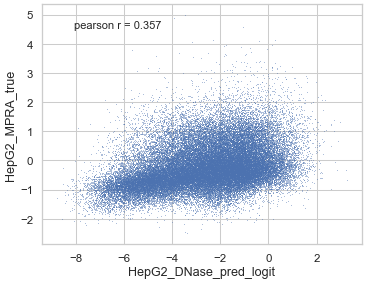

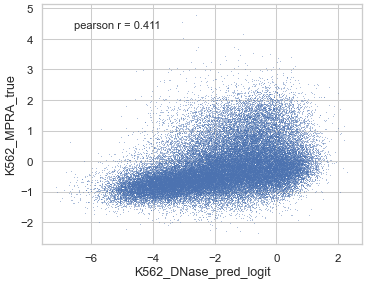

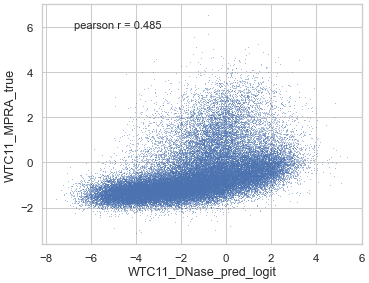

In [18]:
# cell_type = 'HepG2'
# assay = 'DNase'

for cell_type in cell_types:
    for assay in ['DNase']:
        indice = find_indice_precise(info_df, cell_types_possible_dict[cell_type], [assay])
        value = Sei_pred[:, indice].mean(axis=1)
        main_df[f'{cell_type}_{assay}_pred'] = value
        print(f'{cell_type}_{assay}_pred mean = {value.mean()}')
        plot_logit(main_df, cell_type, assay)

In [19]:
# cell_type_specific_assays_list = []

# for cell_type in ['HepG2', 'K562', 'SKNSH']:
#     indice = find_indice(info_df, cell_type, '')
#     assays = set(info_df.iloc[indice]['assay'])
#     cell_type_specific_assays_list.append(assays)

# intersect_assays = list(set.intersection(*cell_type_specific_assays_list))
# print(len(intersect_assays))

# save_txt('data/intersect_assays.txt', intersect_assays)

# cell_types = ['HepG2', 'K562', 'SKNSH']
# assays = load_txt('data/sei_intersect_assays.txt')

# for cell_type in cell_types:
#     for assay in assays:
#         compute_pred(main_df, info_df, Gosai_designed_sei_pred, cell_type, assay)

In [25]:
cell_type_columns_dict = {}
for cell_type in cell_types:
    cell_type_columns_dict[cell_type] = [f'{cell_type}_{assay}_pred_logit' for assay in assays]

# data_split_dict = {
#     'train': ['control', 'DHS_natural', 'Malinois_natural'],
#     'valid': ['AdaLead', 'FastSeqProp', 'Simulated_Annealing'],
# }

data_split_column = 'chr'
data_split_dict = {
    'train': ['chr'+str(i) for i in range(3,23)],
    'valid': ['chr1'],
}

In [36]:
from sklearn.linear_model import LinearRegression, ElasticNet

for cell_type in cell_types:
    # cell_type = 'HepG2'
    data_split = 'train'
    print(f'train model by {cell_type} {data_split} data')
    df = main_df[main_df[data_split_column].isin(data_split_dict[data_split])]
    X_train = np.array(df[cell_type_columns_dict[cell_type]])
    y_train = np.array(df[cell_type])

    # model = LinearRegression()
    model = ElasticNet(alpha=1e-2, l1_ratio=1)
    model.fit(X_train, y_train)

    # train set, same seq and cell type

    for cell_type in cell_types:
        for data_split in ['train', 'valid']:
            df = main_df[main_df[data_split_column].isin(data_split_dict[data_split])]
            X_valid = np.array(df[cell_type_columns_dict[cell_type]])
            y_valid = np.array(df[cell_type])
            y_pred = model.predict(X_valid)
            r = pearsonr(y_valid, y_pred)[0]
            print(f"{cell_type} {data_split} Pearson's r: {r:.3f}")

train model by HepG2 train data
HepG2 train Pearson's r: 0.609
HepG2 valid Pearson's r: 0.630
K562 train Pearson's r: 0.456
K562 valid Pearson's r: 0.420
WTC11 train Pearson's r: 0.252
WTC11 valid Pearson's r: 0.236
train model by K562 train data
HepG2 train Pearson's r: 0.461
HepG2 valid Pearson's r: 0.479
K562 train Pearson's r: 0.651
K562 valid Pearson's r: 0.639
WTC11 train Pearson's r: 0.279
WTC11 valid Pearson's r: 0.271
train model by WTC11 train data
HepG2 train Pearson's r: 0.369
HepG2 valid Pearson's r: 0.403
K562 train Pearson's r: 0.536
K562 valid Pearson's r: 0.530
WTC11 train Pearson's r: 0.619
WTC11 valid Pearson's r: 0.632


In [33]:
top_index = np.abs(model.coef_).argsort()[::-1][:10]

for i in top_index:
    print(assays[i], model.coef_[i])

EZH2 -0.43788853
H3K4me3 0.3095603
DNase 0.25434357
H3K27ac -0.17468923
H3K36me3 0.06585696
H3K9me3 0.0540173
H3K27me3 -0.008493162
H3K9ac 0.0
H3K4me1 -0.0


In [38]:
from sklearn.linear_model import LinearRegression, ElasticNet

cell_type = 'HepG2'
data_split = 'train'
df = main_df[main_df[data_split_column].isin(data_split_dict[data_split])]
X_train1 = np.array(df[cell_type_columns_dict[cell_type]])
y_train1 = np.array(df[cell_type])

cell_type = 'K562'
data_split = 'train'
df = main_df[main_df[data_split_column].isin(data_split_dict[data_split])]
X_train2 = np.array(df[cell_type_columns_dict[cell_type]])
y_train2 = np.array(df[cell_type])

X_train = np.concatenate([X_train1, X_train2])
y_train = np.concatenate([y_train1, y_train2])


model = ElasticNet(alpha=0.01, l1_ratio=1)
model.fit(X_train, y_train)

# train set, same seq and cell type

for cell_type in cell_types:
    for data_split in ['train', 'valid']:
        df = main_df[main_df[data_split_column].isin(data_split_dict[data_split])]
        X_valid = np.array(df[cell_type_columns_dict[cell_type]])
        y_valid = np.array(df[cell_type])
        y_pred = model.predict(X_valid)
        r = pearsonr(y_valid, y_pred)[0]
        print(f"{cell_type} {data_split} Pearson's r: {r:.3f}")

HepG2 train Pearson's r: 0.506
HepG2 valid Pearson's r: 0.532
K562 train Pearson's r: 0.614
K562 valid Pearson's r: 0.598
WTC11 train Pearson's r: 0.438
WTC11 valid Pearson's r: 0.457


In [12]:
# cell_type = 'HepG2'
# cell_type_2 = 'K562'
# assay = 'Dnase'

# x = main_df[f'{cell_type}_{assay}_pred_logit']
# y = main_df[cell_type_2]
# r = pearsonr(x, y)[0]
# print(f'pearson r = {r:.3f}')

# plt.figure(figsize=(8, 6))
# sns.scatterplot(x=x, y=y, s=1, edgecolor=None)
# plt.xlabel(f'{cell_type}_{assay}_pred_logit')
# plt.ylabel(f'{cell_type_2}_MPRA_true')
# plt.text(x=0.1, y=0.9, s=f'pearson r = {r:.3f}', transform=plt.gca().transAxes, fontsize=16)
# plt.savefig(f'figures/{cell_type}_{assay}_pred_logit_1.png', dpi=300, bbox_inches='tight')

In [13]:
# cell_type = 'K562'
# cell_type_2 = 'HepG2'
# assay = 'Dnase'

# x = main_df[f'{cell_type}_{assay}_pred_logit']
# y = main_df[cell_type_2]
# r = pearsonr(x, y)[0]
# print(f'pearson r = {r:.3f}')

# plt.figure(figsize=(8, 6))
# sns.scatterplot(x=x, y=y, s=1, edgecolor=None)
# plt.xlabel(f'{cell_type}_{assay}_pred_logit')
# plt.ylabel(f'{cell_type_2}_MPRA_true')
# plt.text(x=0.1, y=0.9, s=f'pearson r = {r:.3f}', transform=plt.gca().transAxes, fontsize=16)
# plt.savefig(f'figures/{cell_type}_{assay}_pred_logit_1.png', dpi=300, bbox_inches='tight')

pearson r = 0.867


KeyError: 'SKNSH_DNase_pred'

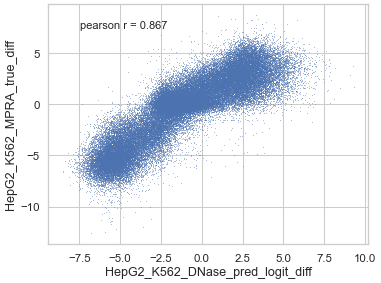

In [16]:
plot_logit_diff(main_df, 'HepG2', 'K562', 'DNase')
plot_logit_diff(main_df, 'HepG2', 'SKNSH', 'DNase')
plot_logit_diff(main_df, 'K562', 'SKNSH', 'DNase')